# data loading and libraries  

In [ ]:
!pip install lightgbm

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
import shap
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Download dataset (BRFSS diabetes dataset)
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

print("Dataset path:", path)

100%|██████████| 6.03M/6.03M [00:06<00:00, 1.05MB/s]

Extracting files...
Dataset path: /home/seif_khashaba/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1


In [ ]:
df = pd.read_csv(path + "/diabetes_binary_health_indicators_BRFSS2015.csv")

# D.R.E.A.M: diabetes risk via explainable AI modeling (khaled)

XGBoost


In [ ]:
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

XGBoost
Accuracy: 0.8667612740460423
F1: 0.2842016094875053


LightGBM

In [ ]:
lgbm = LGBMClassifier()
lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)

print("LightGBM")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

[LightGBM] [Info] Number of positive: 174595, number of negative: 174595
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008357 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5355
[LightGBM] [Info] Number of data points in the train set: 349190, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM
Accuracy: 0.8663079470198676
F1: 0.3038078620548086


# Xai

In [ ]:
!pip install lime
import lime
from lime import lime_tabular

Generating SHAP summary plots...

--- SHAP Summary: Random Forest ---


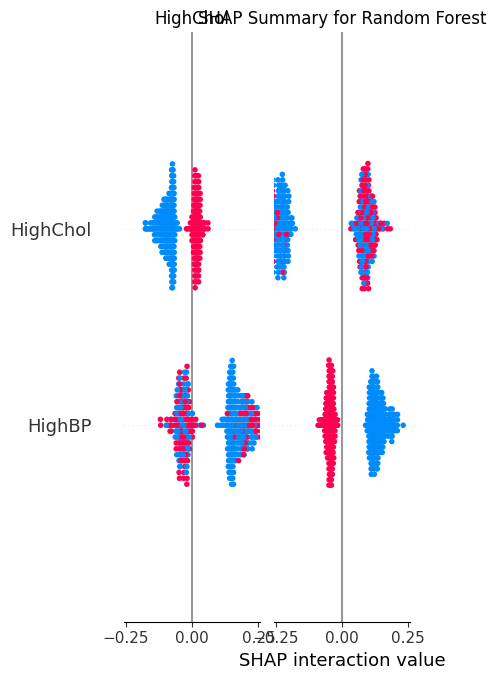


--- SHAP Summary: XGBoost ---


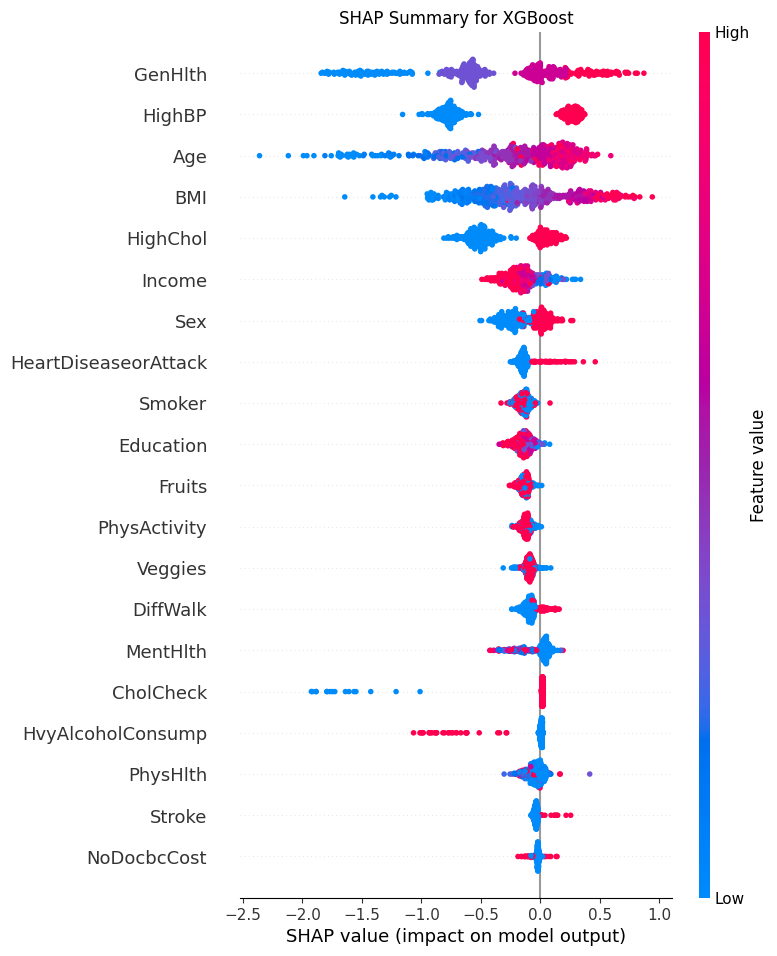


--- SHAP Summary: LightGBM ---


/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


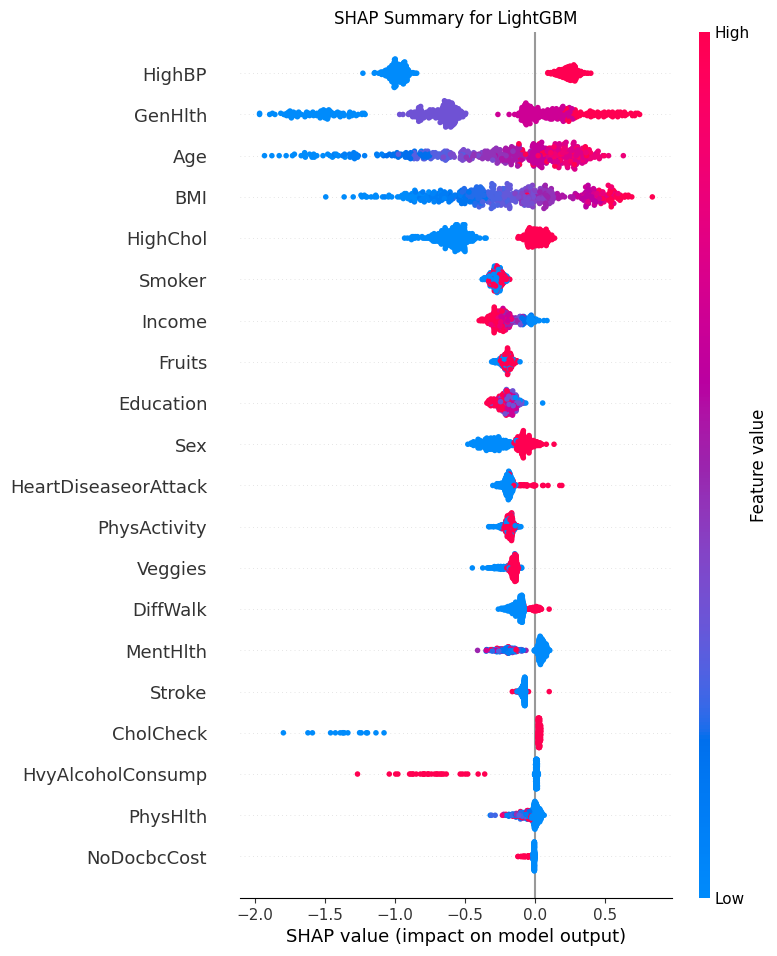


--- SHAP Summary: CatBoost ---


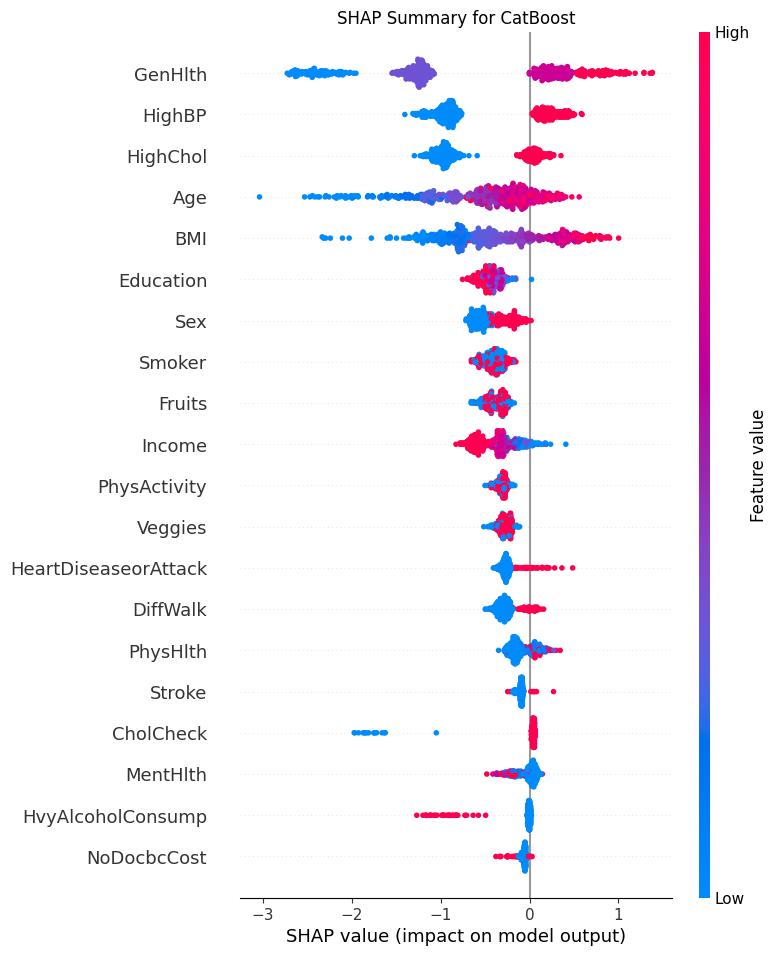


Generating LIME local explanations for a sample instance...

--- LIME Explanation: Logistic Regression (Instance 0) ---


/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be 

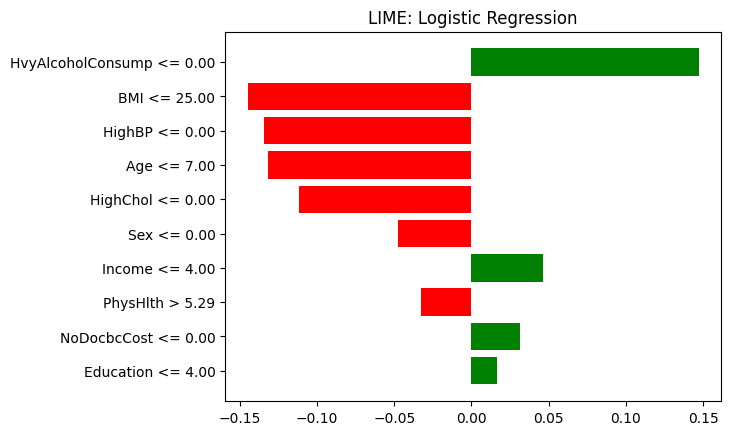


--- LIME Explanation: KNN (Instance 0) ---


/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be 

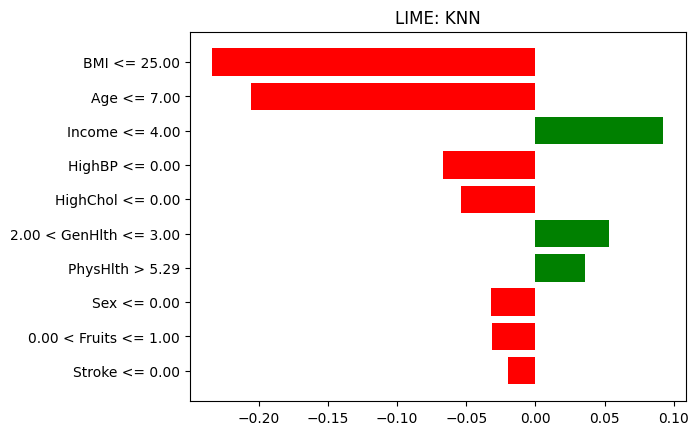


--- LIME Explanation: Random Forest (Instance 0) ---


/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/seif_khashaba/miniconda3/envs/tf_env/lib/python3.12/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be 

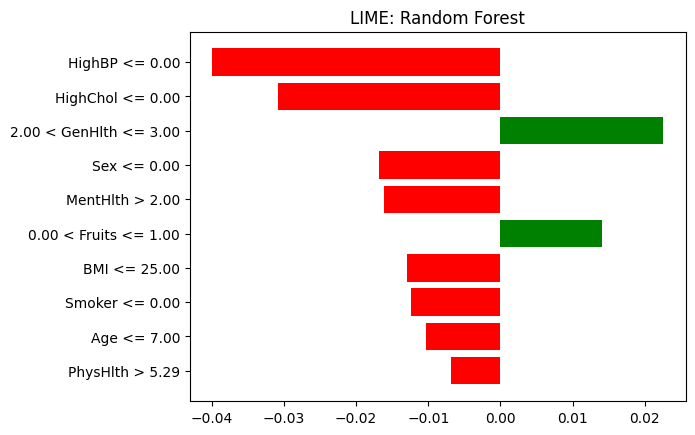

In [ ]:


# --- SHAP for Tree-based Models ---
print("Generating SHAP summary plots...")

tree_models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat
}

for name, model in tree_models.items():
    print(f"\n--- SHAP Summary: {name} ---")
    explainer = shap.TreeExplainer(model)
    # Using a subset of test data for faster calculation if necessary,
    # but summary_plot is usually efficient with TreeExplainer
    shap_values = explainer.shap_values(X_test.iloc[:500])

    # Handle multi-output (RF/LGBM) vs single-output (XGB/Cat)
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], X_test.iloc[:500], show=False)
    else:
        shap.summary_plot(shap_values, X_test.iloc[:500], show=False)
    plt.title(f"SHAP Summary for {name}")
    plt.show()

# --- LIME for Local Explanations ---
print("\nGenerating LIME local explanations for a sample instance...")

# Define LIME Explainer
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['No Diabetes', 'Diabetes'],
    mode='classification'
)

# Select a specific instance to explain (e.g., first index of X_test)
i = 0
instance = X_test.iloc[i]

# Models to explain with LIME
lime_targets = {
    "Logistic Regression": log_model,
    "KNN": knn,
    "Random Forest": rf
}

for name, model in lime_targets.items():
    print(f"\n--- LIME Explanation: {name} (Instance {i}) ---")
    exp = explainer_lime.explain_instance(
        data_row=instance,
        predict_fn=model.predict_proba
    )
    exp.as_pyplot_figure()
    plt.title(f"LIME: {name}")
    plt.show()

--- Permutation Importance (Top Models) ---

Calculating Permutation Importance for Random Forest...


/tmp/ipykernel_2136/3866173865.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])


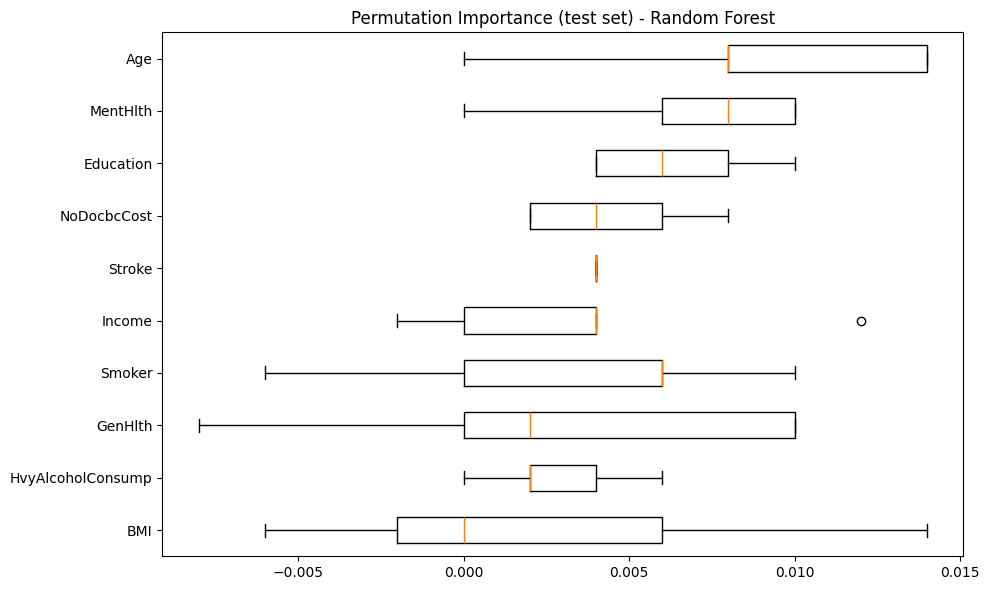


Calculating Permutation Importance for XGBoost...


/tmp/ipykernel_2136/3866173865.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])


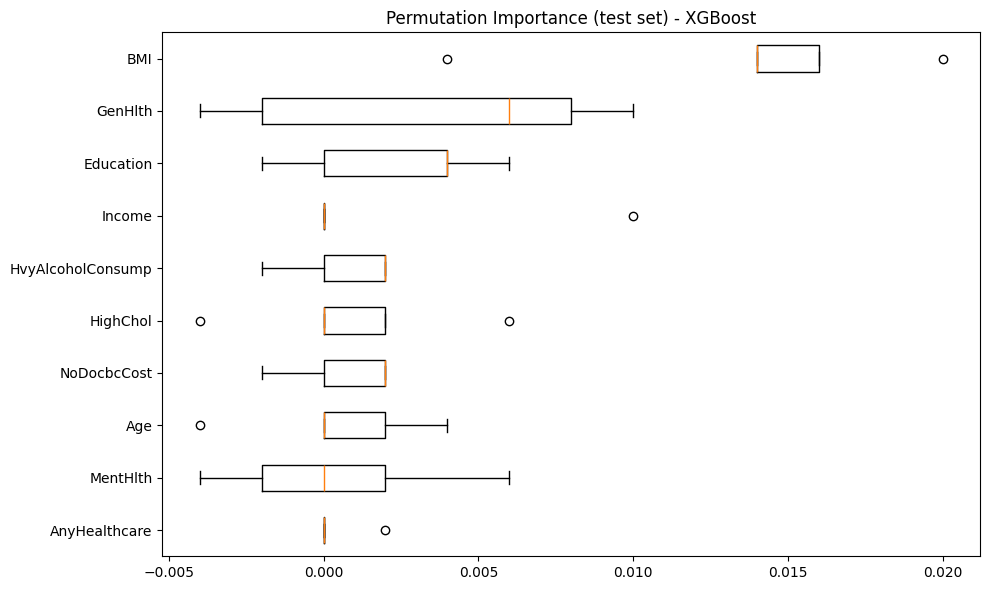

/tmp/ipykernel_2136/3866173865.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])



Calculating Permutation Importance for Logistic Reg...


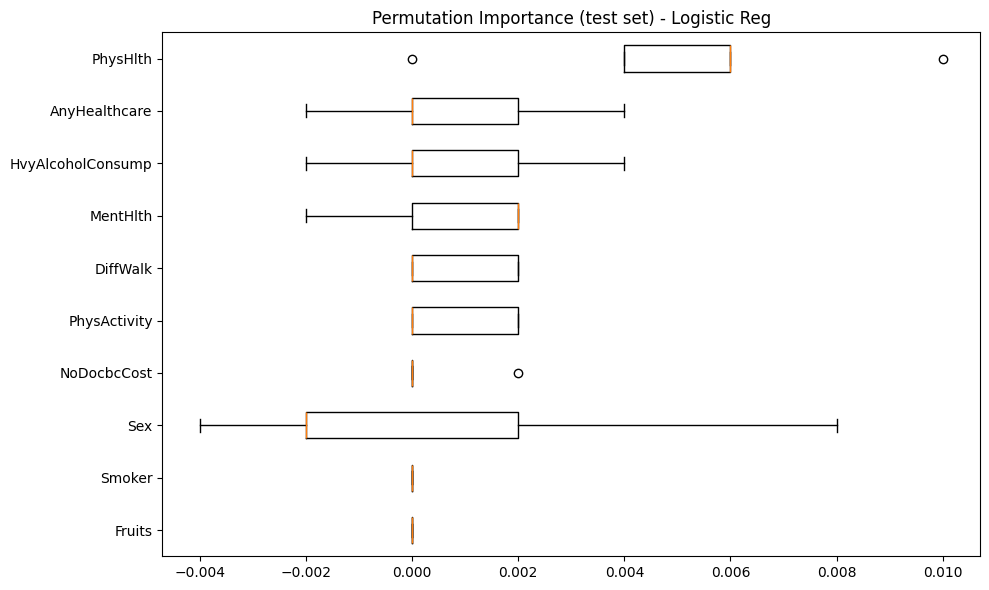

In [ ]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# 3. Permutation Importance
print("--- Permutation Importance (Top Models) ---")
models_to_inspect = {"Random Forest": rf, "XGBoost": xgb, "Logistic Reg": log_model}

for name, model in models_to_inspect.items():
    print(f"\nCalculating Permutation Importance for {name}...")
    result = permutation_importance(model, X_test.iloc[:500], y_test.iloc[:500], n_repeats=5, random_state=42)
    sorted_idx = result.importances_mean.argsort()[-10:]

    plt.figure(figsize=(10, 6))
    plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])
    plt.title(f"Permutation Importance (test set) - {name}")
    plt.tight_layout()
    plt.show()

--- Partial Dependence Plots (Top 2 Features) ---

Generating PDP for Random Forest...


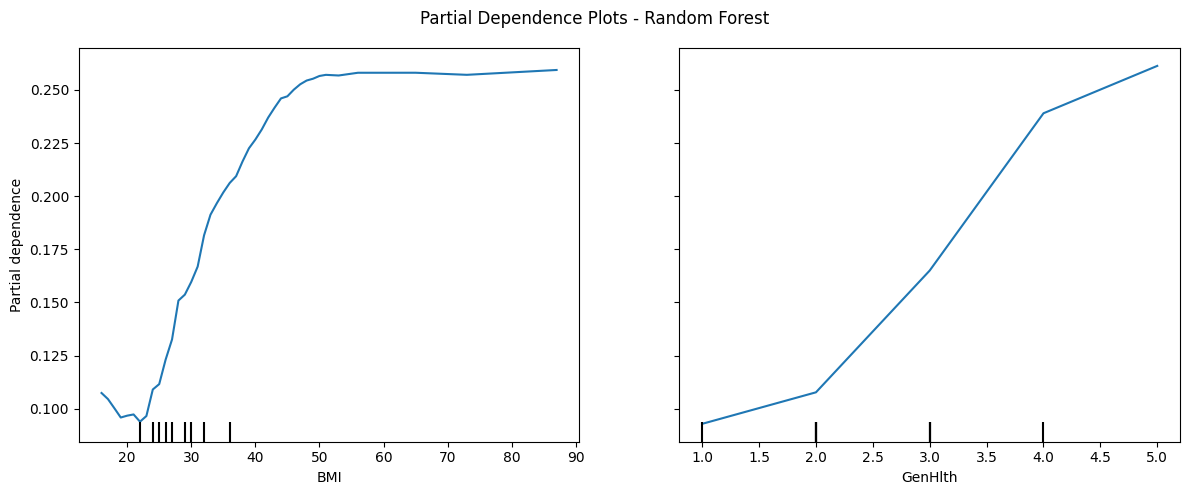


Generating PDP for XGBoost...


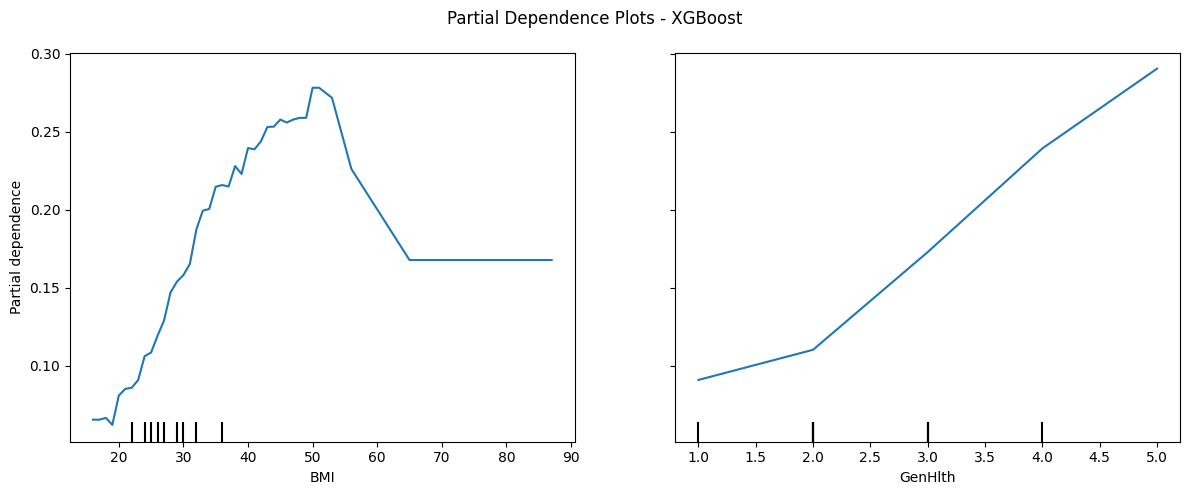


Generating PDP for Logistic Reg...


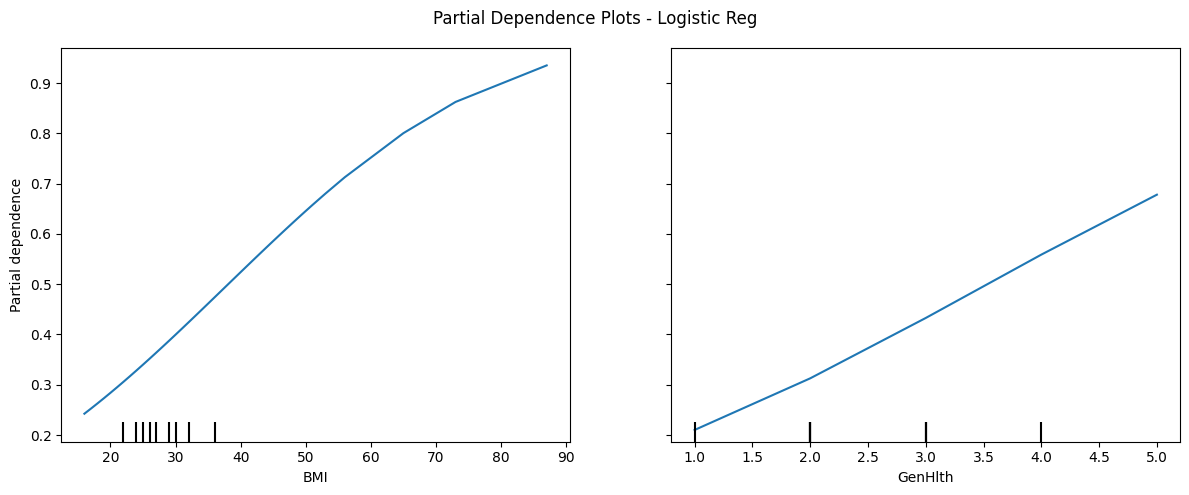

In [ ]:
# 4. Partial Dependence Plots (PDP)
print("--- Partial Dependence Plots (Top 2 Features) ---")
# BMI and GenHlth are typically high-impact features
features = ['BMI', 'GenHlth']

for name, model in models_to_inspect.items():
    print(f"\nGenerating PDP for {name}...")
    fig, ax = plt.subplots(figsize=(12, 5))
    PartialDependenceDisplay.from_estimator(model, X_train.iloc[:1000], features, ax=ax)
    plt.suptitle(f"Partial Dependence Plots - {name}")
    plt.tight_layout()
    plt.show()

--- 5. Linear Model Coefficients (Logistic Regression) ---


/tmp/ipykernel_2136/236284726.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='coolwarm')


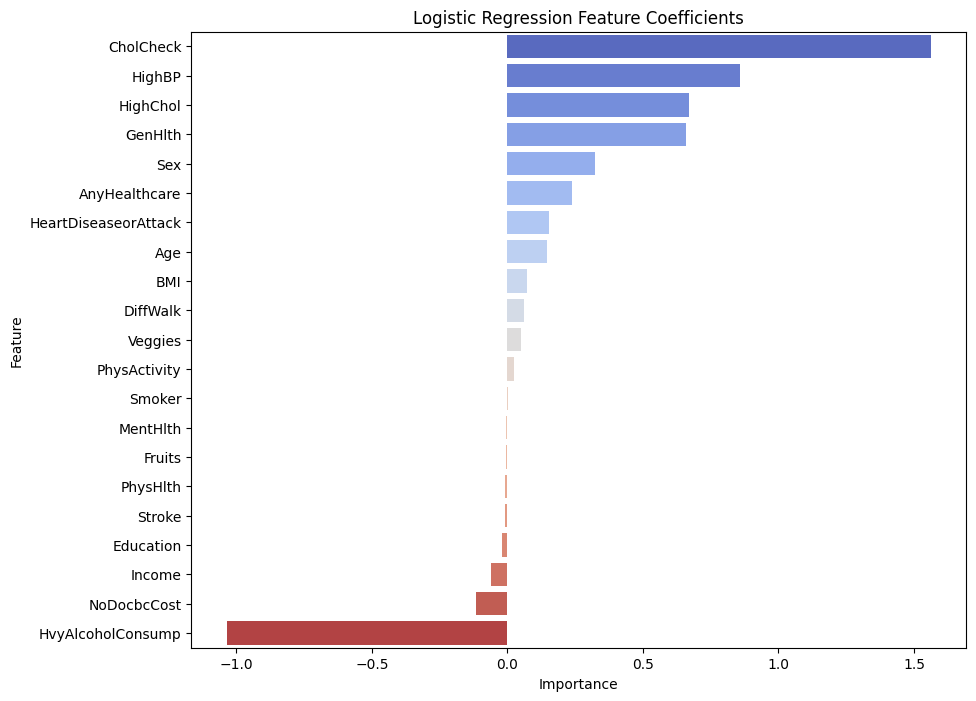

In [ ]:
print("--- 5. Linear Model Coefficients (Logistic Regression) ---")
importance = log_model.coef_[0]
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='coolwarm')
plt.title('Logistic Regression Feature Coefficients')
plt.show()

PyALE._ALE_generic:INFO: Continuous feature detected.


--- 6. Accumulated Local Effects (ALE) Plots ---


<Figure size 800x500 with 0 Axes>

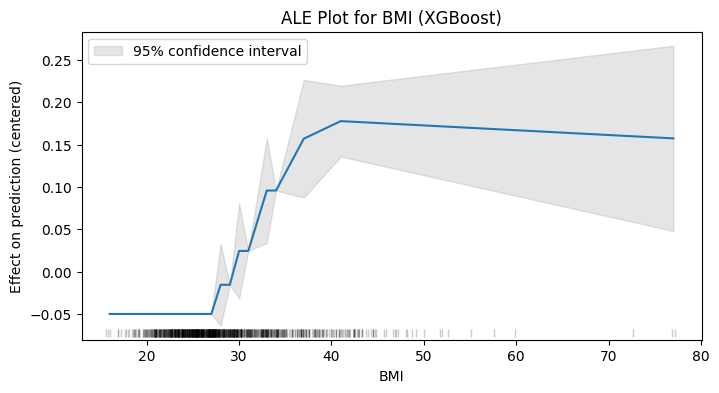

In [ ]:
!pip install PyALE
from PyALE import ale

print("--- 6. Accumulated Local Effects (ALE) Plots ---")
# BMI is a continuous feature suitable for ALE

# Note: PyALE expects a predict function
def model_predict(X_in):
    return xgb.predict(X_in)

# Using a subset for speed
plt.figure(figsize=(8, 5))
ale_eff = ale(X=X_test.iloc[:1000], model=xgb, feature=['BMI'], grid_size=20, include_CI=True)
plt.title('ALE Plot for BMI (XGBoost)')
plt.show()

| Model       | Accuracy       | AUC            |
| ----------- | -------------- | -------------- |
| **XGBoost** | **96.07%**     | **99.29%**     |
| CatBoost    | Slightly lower | Slightly lower |


| Model         | AUC    | F1-score | Recall          |
| ------------- | ------ | -------- | --------------- |
| Random Forest | > 0.83 | ~0.78    | **0.89 (best)** |
| XGBoost       | > 0.83 | ~0.78    | Slightly lower  |
| LightGBM      | > 0.83 | ~0.78    | Slightly lower  |


| Model               | Accuracy       | AUROC    |
| ------------------- | -------------- | -------- |
| Logistic Regression | Lower          | ~0.75    |
| Random Forest       | Higher         | ~0.78    |
| Gradient Boosting   | **82% (best)** | **0.80** |
| XGBoost             | Close to GB    | ~0.79    |


| Model                | Accuracy                 |
| -------------------- | ------------------------ |
| Extra Trees (ET)     | **97.23% (multi-class)** |
| Extra Trees (binary) | **97.45%**               |
| Other models         | 77% – 94%                |
